Loaded 732 samples across 4 populations.
label
Intermissa    183
Sahariens     183
Moldova       183
Hungary       183
Name: count, dtype: int64

Final cleaned dataset: 732 rows, 24 features.
label
Intermissa    183
Sahariens     183
Moldova       183
Hungary       183
Name: count, dtype: int64

Feature columns (24): ['skel_pixel_count', 'skel_density', 'skel_height', 'skel_width', 'skel_aspect_ratio', 'skel_cx', 'skel_cy', 'skel_x_std', 'skel_y_std', 'skel_x_min', 'skel_x_max', 'skel_y_min', 'skel_y_max', 'junc_count', 'junc_cx', 'junc_cy', 'junc_x_std', 'junc_y_std', 'junc_x_min', 'junc_x_max', 'junc_y_min', 'junc_y_max', 'junc_hull_area', 'junc_hull_perimeter']
Feature-to-sample ratio: 0.033 (low ratio = lower overfitting risk)

Best hyperparameters: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
Best cross-validated training accuracy: 0.870
CV fold scores: [0.846 0.906 0.906 0.88  0.812] (std=0.036)


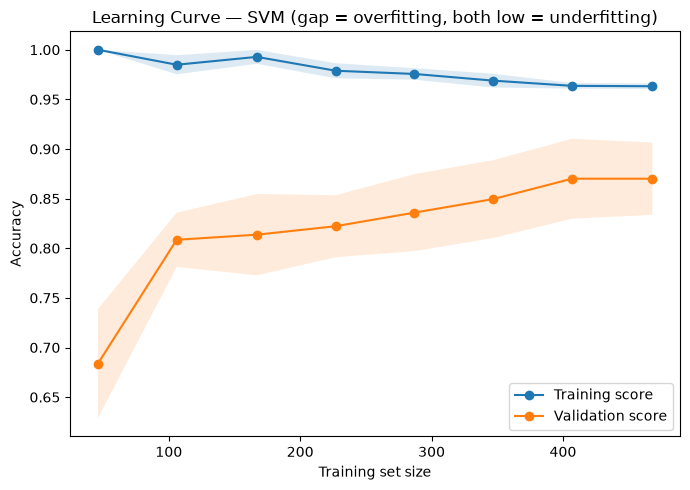


Test accuracy: 0.884

Classification report:
              precision    recall  f1-score   support

     Hungary       0.81      0.78      0.79        37
  Intermissa       0.94      0.86      0.90        36
     Moldova       0.80      0.89      0.85        37
   Sahariens       1.00      1.00      1.00        37

    accuracy                           0.88       147
   macro avg       0.89      0.88      0.88       147
weighted avg       0.89      0.88      0.88       147



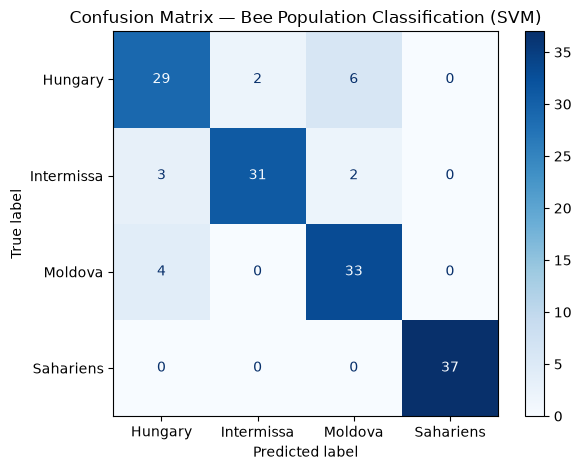


Saved model, scaler, and label encoder to svm_bee_population_model.joblib


In [1]:
"""
Bee wing population classifier — SVM
-------------------------------------
Converts the `skeleton` (serialized binary image) and `junctions`
(serialized variable-length list of x,y points) columns into FIXED-LENGTH
numeric feature vectors, then trains + tunes an SVM across the 4
populations (Intermissa / Sahariens / Moldova / Hungary).

Why fixed-length aggregation:
  - `skeleton` strings encode a full 2D binary image, one row of pixels per
    ';'-separated chunk, pixels comma-separated. Image height/width differ
    per sample (different crops/original photos), so raw pixels can't be
    used directly as SVM input.
  - `junctions` strings encode a variable number of (x, y) points per wing.
  - SVM (like most classical ML models) requires every sample to have the
    SAME number of features, so both columns are summarized into fixed
    numeric statistics (counts, centroid, spread, bounding box, shape).
"""

import os
import numpy as np
import pandas as pd
from scipy.spatial import ConvexHull, QhullError
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, learning_curve, cross_val_score
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib

# ============================================================
# 0. CONFIG
# ============================================================
FILES = {
    "Intermissa": "AF_Intermissa.csv",
    "Sahariens":  "AF_sahariens.csv",
    "Moldova":    "AF_Moldova.csv",
    "Hungary":    "AF_Hungary.csv",
}

RANDOM_STATE = 42

# ============================================================
# 1. PARSERS
# ============================================================
def parse_skeleton_matrix(val):
    """Reconstruct the 2D binary skeleton image from its serialized string."""
    if pd.isna(val) or str(val).strip() == "":
        return np.empty((0, 0), dtype=np.uint8)

    rows = [r for r in str(val).split(";") if r != ""]
    matrix = []
    for r in rows:
        try:
            matrix.append(np.array(r.split(","), dtype=np.uint8))
        except ValueError:
            continue
    if not matrix:
        return np.empty((0, 0), dtype=np.uint8)

    # Guard against ragged rows (shouldn't happen, but be defensive)
    width = min(len(r) for r in matrix)
    matrix = [r[:width] for r in matrix]
    return np.vstack(matrix)


def parse_junctions(val):
    """'451,29;454,36;373,43' -> np.array([[451,29],[454,36],[373,43]])"""
    if pd.isna(val) or str(val).strip() == "":
        return np.empty((0, 2), dtype=np.float32)

    pairs = []
    for chunk in str(val).split(";"):
        chunk = chunk.strip()
        if not chunk:
            continue
        parts = chunk.split(",")
        if len(parts) == 2:
            try:
                pairs.append((float(parts[0]), float(parts[1])))
            except ValueError:
                continue
    return np.array(pairs, dtype=np.float32) if pairs else np.empty((0, 2), dtype=np.float32)


# ============================================================
# 2. FEATURE EXTRACTION (fixed-length, regardless of input size)
# ============================================================
def skeleton_features(val):
    arr = parse_skeleton_matrix(val)
    h, w = arr.shape

    if h == 0 or w == 0:
        return pd.Series({
            "skel_pixel_count": np.nan, "skel_density": np.nan,
            "skel_height": np.nan, "skel_width": np.nan, "skel_aspect_ratio": np.nan,
            "skel_cx": np.nan, "skel_cy": np.nan,
            "skel_x_std": np.nan, "skel_y_std": np.nan,
            "skel_x_min": np.nan, "skel_x_max": np.nan,
            "skel_y_min": np.nan, "skel_y_max": np.nan,
        })

    ys, xs = np.where(arr > 0)
    count = len(xs)

    return pd.Series({
        "skel_pixel_count": count,
        "skel_density": count / (h * w),
        "skel_height": h,
        "skel_width": w,
        "skel_aspect_ratio": w / h,
        "skel_cx": xs.mean() if count else np.nan,
        "skel_cy": ys.mean() if count else np.nan,
        "skel_x_std": xs.std() if count else np.nan,
        "skel_y_std": ys.std() if count else np.nan,
        "skel_x_min": xs.min() if count else np.nan,
        "skel_x_max": xs.max() if count else np.nan,
        "skel_y_min": ys.min() if count else np.nan,
        "skel_y_max": ys.max() if count else np.nan,
    })


def junction_features(val):
    arr = parse_junctions(val)
    count = len(arr)

    feats = {
        "junc_count": count,
        "junc_cx": np.nan, "junc_cy": np.nan,
        "junc_x_std": np.nan, "junc_y_std": np.nan,
        "junc_x_min": np.nan, "junc_x_max": np.nan,
        "junc_y_min": np.nan, "junc_y_max": np.nan,
        "junc_hull_area": np.nan, "junc_hull_perimeter": np.nan,
    }
    if count == 0:
        return pd.Series(feats)

    xs, ys = arr[:, 0], arr[:, 1]
    feats.update({
        "junc_cx": xs.mean(), "junc_cy": ys.mean(),
        "junc_x_std": xs.std(), "junc_y_std": ys.std(),
        "junc_x_min": xs.min(), "junc_x_max": xs.max(),
        "junc_y_min": ys.min(), "junc_y_max": ys.max(),
    })

    # Convex hull needs >= 3 non-collinear points; guard against failure
    if count >= 3:
        try:
            hull = ConvexHull(arr)
            feats["junc_hull_area"] = hull.volume       # 2D hull "volume" = area
            feats["junc_hull_perimeter"] = hull.area     # 2D hull "area" = perimeter
        except QhullError:
            pass

    return pd.Series(feats)


def normalize_label(raw_label, population_name):
    """Standardize inconsistent label strings (e.g. 'A.F Hungary' vs 'Hungary')
    to the canonical population name passed via FILES."""
    return population_name


# ============================================================
# 3. LOAD + BUILD FEATURE TABLE
# ============================================================
frames = []
for pop_name, path in FILES.items():
    if not os.path.exists(path):
        print(f"[WARN] Missing file, skipping: {path}")
        continue

    df = pd.read_csv(path)

    skel_feats = df["skeleton"].apply(skeleton_features)
    junc_feats = df["junctions"].apply(junction_features)

    combined = pd.concat([df[["id"]], skel_feats, junc_feats], axis=1)
    combined["label"] = normalize_label(df["label"], pop_name)  # standardize regardless of raw string
    frames.append(combined)

full_df = pd.concat(frames, ignore_index=True)
print(f"Loaded {len(full_df)} samples across {full_df['label'].nunique()} populations.")
print(full_df["label"].value_counts())

# ============================================================
# 4. CLEANING
# ============================================================
full_df = full_df.drop(columns=["id"], errors="ignore")

# Drop any column that is entirely NaN across all samples
all_nan_cols = [c for c in full_df.columns if c != "label" and full_df[c].isna().all()]
if all_nan_cols:
    print(f"Dropping all-NaN columns: {all_nan_cols}")
    full_df = full_df.drop(columns=all_nan_cols)

# Drop rows with any remaining missing values (failed image parses)
before = len(full_df)
full_df = full_df.dropna()
after = len(full_df)
if before != after:
    print(f"Dropped {before - after} rows with missing/failed feature values.")

# Drop exact duplicate rows, if any
dupes = full_df.duplicated().sum()
if dupes:
    print(f"Dropping {dupes} duplicate rows.")
    full_df = full_df.drop_duplicates()

print(f"\nFinal cleaned dataset: {full_df.shape[0]} rows, {full_df.shape[1] - 1} features.")
print(full_df["label"].value_counts())

# ============================================================
# 5. FEATURES / TARGET
# ============================================================
X = full_df.drop(columns=["label"])
y = full_df["label"]

le = LabelEncoder()
y_enc = le.fit_transform(y)

print(f"\nFeature columns ({X.shape[1]}): {list(X.columns)}")
print(f"Feature-to-sample ratio: {X.shape[1] / X.shape[0]:.3f} "
      f"(low ratio = lower overfitting risk)")

# ============================================================
# 6. TRAIN/TEST SPLIT (stratified — preserves class balance)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_enc
)

# ============================================================
# 7. SCALING (fit on train only — avoids leakage into test set)
# ============================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================
# 8. HYPERPARAMETER TUNING (controls the over/underfitting tradeoff)
# ============================================================
# C: smaller = more regularization (less overfitting, risk of underfitting)
#    larger  = less regularization (risk of overfitting)
# gamma: smaller = smoother/simpler decision boundary (risk of underfitting)
#        larger  = tighter fit to training points (risk of overfitting)
param_grid = {
    "C":      [0.01, 0.1, 1, 10, 100],
    "gamma":  ["scale", 0.001, 0.01, 0.1, 1],
    "kernel": ["rbf", "linear"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(SVC(), param_grid, cv=cv, scoring="accuracy", n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print(f"\nBest hyperparameters: {grid.best_params_}")
print(f"Best cross-validated training accuracy: {grid.best_score_:.3f}")

best_model = grid.best_estimator_

# Sanity check: cross-val score spread (large gap between folds -> unstable / overfitting risk)
cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=cv)
print(f"CV fold scores: {np.round(cv_scores, 3)} (std={cv_scores.std():.3f})")

# ============================================================
# 9. LEARNING CURVE (diagnoses over/underfitting visually)
# ============================================================
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train_scaled, y_train,
    cv=cv, scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
)

plt.figure(figsize=(7, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Training score")
plt.plot(train_sizes, val_scores.mean(axis=1), "o-", label="Validation score")
plt.fill_between(train_sizes,
                  train_scores.mean(axis=1) - train_scores.std(axis=1),
                  train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15)
plt.fill_between(train_sizes,
                  val_scores.mean(axis=1) - val_scores.std(axis=1),
                  val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15)
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.title("Learning Curve — SVM (gap = overfitting, both low = underfitting)")
plt.legend()
plt.tight_layout()
plt.savefig("learning_curve.png", dpi=150)
plt.show()

# ============================================================
# 10. FINAL EVALUATION ON HELD-OUT TEST SET
# ============================================================
y_pred = best_model.predict(X_test_scaled)

print(f"\nTest accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Bee Population Classification (SVM)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# ============================================================
# 11. SAVE MODEL + PREPROCESSING (for reuse on new wing images)
# ============================================================
joblib.dump({
    "model": best_model,
    "scaler": scaler,
    "label_encoder": le,
    "feature_columns": list(X.columns),
}, "svm_bee_population_model.joblib")

print("\nSaved model, scaler, and label encoder to svm_bee_population_model.joblib")